In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from scipy.stats import rankdata

import lightgbm as lgb
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# --- Данные ---
X_train_full = pd.read_csv('../data/processed/X_train.csv')
X_test       = pd.read_csv('../data/processed/X_test.csv')
y_train_full = pd.read_csv('../data/processed/y_train.csv')['Class'].astype(int).values
y_test       = pd.read_csv('../data/processed/y_test.csv')['Class'].astype(int).values

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, stratify=y_train_full, random_state=42
)

print(f"Train: {X_tr.shape}, фрод: {y_tr.sum()}")
print(f"Val:   {X_val.shape}, фрод: {y_val.sum()}")
print(f"Test:  {X_test.shape}, фрод: {y_test.sum()}")

# --- Бизнес-параметры ---
AVG_FRAUD_AMOUNT = 122.0
COST_FP = 5.0

Train: (181584, 30), фрод: 302
Val:   (45396, 30), фрод: 76
Test:  (56746, 30), фрод: 95


In [2]:
def metrics_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'fn': int(fn), 'fp': int(fp), 'tp': int(tp),
        'business_loss': fn * AVG_FRAUD_AMOUNT + fp * COST_FP
    }

def find_min_cost_threshold(y_true, y_proba, grid=None):
    if grid is None:
        grid = np.arange(0.01, 1.00, 0.01)
    best_thr, best_loss = 0.5, float('inf')
    for thr in grid:
        m = metrics_at_threshold(y_true, y_proba, thr)
        if m['business_loss'] < best_loss:
            best_loss = m['business_loss']
            best_thr = thr
    return best_thr, best_loss

def full_eval(name, y_proba_test, thr=0.5):
    m = metrics_at_threshold(y_test, y_proba_test, thr)
    return {
        'Модель': name,
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba_test), 4),
        'PR-AUC':   round(average_precision_score(y_test, y_proba_test), 4),
        'Recall':   round(m['recall'], 4),
        'Precision':round(m['precision'], 4),
        'F1':       round(m['f1'], 4),
        'FN': m['fn'], 'FP': m['fp'],
        'Threshold': round(thr, 3),
        'Business loss': m['business_loss']
    }

## XGBoost

In [3]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_base = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_base.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"Best iteration: {xgb_base.best_iteration}")
print(f"Best PR-AUC on val: {xgb_base.best_score:.4f}")

val_proba_xgb  = xgb_base.predict_proba(X_val)[:, 1]
test_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]
print(f"Test PR-AUC : {average_precision_score(y_test, test_proba_xgb):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba_xgb):.4f}")

scale_pos_weight = 600.27
[0]	validation_0-aucpr:0.43679
[100]	validation_0-aucpr:0.84803
[200]	validation_0-aucpr:0.86824
[300]	validation_0-aucpr:0.87308
[360]	validation_0-aucpr:0.87282
Best iteration: 310
Best PR-AUC on val: 0.8734
Test PR-AUC : 0.8144
Test ROC-AUC: 0.9636


## SMOTE

In [4]:
print(f"Before SMOTE: {np.bincount(y_tr)}")

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print(f"After SMOTE:  {np.bincount(y_tr_smote)}")
print(f"Доля фрода после SMOTE: {y_tr_smote.mean()*100:.2f}%")

Before SMOTE: [181282    302]
After SMOTE:  [181282  18128]
Доля фрода после SMOTE: 9.09%


In [5]:
lgbm_smote = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_smote.fit(
    X_tr_smote, y_tr_smote,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
val_proba_lgbm_smote  = lgbm_smote.predict_proba(X_val)[:, 1]
test_proba_lgbm_smote = lgbm_smote.predict_proba(X_test)[:, 1]
print(f"LGBM+SMOTE val PR-AUC : {average_precision_score(y_val, val_proba_lgbm_smote):.4f}")
print(f"LGBM+SMOTE test PR-AUC: {average_precision_score(y_test, test_proba_lgbm_smote):.4f}")

LGBM+SMOTE val PR-AUC : 0.8796
LGBM+SMOTE test PR-AUC: 0.8138


In [6]:
xgb_smote = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)
xgb_smote.fit(X_tr_smote, y_tr_smote, eval_set=[(X_val, y_val)], verbose=False)

val_proba_xgb_smote  = xgb_smote.predict_proba(X_val)[:, 1]
test_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]
print(f"XGB+SMOTE val PR-AUC : {average_precision_score(y_val, val_proba_xgb_smote):.4f}")
print(f"XGB+SMOTE test PR-AUC: {average_precision_score(y_test, test_proba_xgb_smote):.4f}")

XGB+SMOTE val PR-AUC : 0.8800
XGB+SMOTE test PR-AUC: 0.8171


In [7]:
# Загружаем LGBM (Optuna) и LGBM (default) probas
lgbm_optuna = joblib.load('../models/lgbm_optuna_final.pkl')
lgbm_default = joblib.load('../models/best_tree_model.pkl')  # is_unbalance=True

val_proba_lgbm_def  = lgbm_default.predict_proba(X_val)[:, 1]
test_proba_lgbm_def = lgbm_default.predict_proba(X_test)[:, 1]

val_proba_lgbm_opt  = lgbm_optuna.predict_proba(X_val)[:, 1]
test_proba_lgbm_opt = lgbm_optuna.predict_proba(X_test)[:, 1]

smote_compare = pd.DataFrame([
    full_eval('LGBM + is_unbalance',     test_proba_lgbm_def,   0.5),
    full_eval('LGBM + SMOTE',            test_proba_lgbm_smote, 0.5),
    full_eval('XGB + scale_pos_weight',  test_proba_xgb,        0.5),
    full_eval('XGB + SMOTE',             test_proba_xgb_smote,  0.5),
])
print(smote_compare.to_string(index=False))

                Модель  ROC-AUC  PR-AUC  Recall  Precision     F1  FN  FP  Threshold  Business loss
   LGBM + is_unbalance   0.9278  0.7926  0.7789     0.7551 0.7668  21  24        0.5         2682.0
          LGBM + SMOTE   0.9733  0.8138  0.8000     0.7917 0.7958  19  20        0.5         2418.0
XGB + scale_pos_weight   0.9636  0.8144  0.7579     0.9114 0.8276  23   7        0.5         2841.0
           XGB + SMOTE   0.9757  0.8171  0.7895     0.8621 0.8242  20  12        0.5         2500.0



**Результаты на test (threshold=0.5):**

| Модель | ROC-AUC | PR-AUC | Recall | Precision | F1 | FN | FP | Business loss |
|---|---|---|---|---|---|---|---|---|
| LGBM + is_unbalance       | 0.9278 | 0.7926 | 0.7789 | 0.7551 | 0.7668 | 21 | 24 | **\$2682** |
| **LGBM + SMOTE          | 0.9733 | 0.8138 | **0.8000** | 0.7917 | 0.7958 | **19** | 20 | **\$2418** ⭐ |
| XGB + scale_pos_weight    | 0.9636 | 0.8144 | 0.7579 | **0.9114** | **0.8276** | 23 |  **7** | \$2841 |
| XGB + SMOTE               | **0.9757** | **0.8171** | 0.7895 | 0.8621 | 0.8242 | 20 | 12 | \$2500 |

**Ключевые наблюдения:**

1. **SMOTE улучшил ROC-AUC на ~+0.04 у обеих моделей** (0.93 → 0.97 для LGBM, 0.96 → 0.98 для XGB).
   Это значит, что синтетические сэмплы помогают модели лучше **ранжировать** транзакции
   по риску, особенно в «серой зоне».

2. **PR-AUC тоже подрос** (+0.02 у LGBM, +0.003 у XGB) — менее драматично, но стабильно.
   Прирост ROC-AUC > прирост PR-AUC: SMOTE помогает скорее в общем разделении классов,
   чем в самой «голове» ранжирования.

3. **Business loss падает у обеих моделей при SMOTE:**
   - LGBM: \$2682 → **\$2418** (−10%)
   - XGB:  \$2841 → \$2500 (−12%)
   Главная причина — Recall растёт (находим на 2–3 фрода больше), а это \$244–\$366 экономии
   на каждый сохранённый фрод.

4. **Разные стратегии — разные «характеры» моделей:**
   - `class_weight / scale_pos_weight` → агрессивная: высокий Recall, много FP.
   - `SMOTE` → сбалансированная: высокий Recall **и** высокий Precision.
   - **XGB + scale_pos_weight** уникален: ультра-консервативен (всего 7 FP, Precision 91%),
     но пропускает 23 фрода — для бизнеса это **хуже**, чем 24 FP у LGBM.

5. **Почему SMOTE неожиданно помог** (вопреки моему предварительному прогнозу):
   - `sampling_strategy=0.1` оказался удачной точкой — не слишком много синтетики,
     не слишком мало.
   - Признаки `V1..V28` — результат PCA, т.е. **непрерывные и гладкие**.
     SMOTE отлично работает на таком пространстве: интерполяция между соседями
     даёт реалистичные точки без артефактов.
   - Если бы признаки были категориальными или сильно скошенными — SMOTE мог бы навредить.

**Вывод по Части B:**
- Лучшая по бизнес-метрике после Части B — **LGBM + SMOTE** (\$2418, новый рекорд проекта).
- Лучшая по PR-AUC и ROC-AUC — **XGB + SMOTE** (0.8171 / 0.9757).
- Эти модели **обязательно идут в ensemble** в Части C.
- Для production-кандидата теперь два фаворита: `LGBM + SMOTE` (минимальный loss) и
  `XGB + SMOTE` (лучшее ранжирование) — финальный выбор после ensemble.

In [9]:

val_proba_avg  = (val_proba_lgbm_opt + val_proba_xgb) / 2
val_proba_geom = np.sqrt(np.clip(val_proba_lgbm_opt * val_proba_xgb, 1e-9, 1.0))

rank_lgbm_v = rankdata(val_proba_lgbm_opt) / len(val_proba_lgbm_opt)
rank_xgb_v  = rankdata(val_proba_xgb)      / len(val_proba_xgb)
val_proba_rank = (rank_lgbm_v + rank_xgb_v) / 2


test_proba_avg  = (test_proba_lgbm_opt + test_proba_xgb) / 2
test_proba_geom = np.sqrt(np.clip(test_proba_lgbm_opt * test_proba_xgb, 1e-9, 1.0))

rank_lgbm_t = rankdata(test_proba_lgbm_opt) / len(test_proba_lgbm_opt)
rank_xgb_t  = rankdata(test_proba_xgb)      / len(test_proba_xgb)
test_proba_rank = (rank_lgbm_t + rank_xgb_t) / 2

ensemble_compare = pd.DataFrame([
    {'Ensemble': 'LGBM only',       'PR-AUC': average_precision_score(y_test, test_proba_lgbm_opt), 'ROC-AUC': roc_auc_score(y_test, test_proba_lgbm_opt)},
    {'Ensemble': 'XGB only',        'PR-AUC': average_precision_score(y_test, test_proba_xgb),      'ROC-AUC': roc_auc_score(y_test, test_proba_xgb)},
    {'Ensemble': 'Avg(LGBM, XGB)',  'PR-AUC': average_precision_score(y_test, test_proba_avg),      'ROC-AUC': roc_auc_score(y_test, test_proba_avg)},
    {'Ensemble': 'Geom mean',       'PR-AUC': average_precision_score(y_test, test_proba_geom),     'ROC-AUC': roc_auc_score(y_test, test_proba_geom)},
    {'Ensemble': 'Rank avg',        'PR-AUC': average_precision_score(y_test, test_proba_rank),     'ROC-AUC': roc_auc_score(y_test, test_proba_rank)},
])
print(ensemble_compare.round(4).to_string(index=False))

      Ensemble  PR-AUC  ROC-AUC
     LGBM only  0.8145   0.9622
      XGB only  0.8144   0.9636
Avg(LGBM, XGB)  0.8243   0.9653
     Geom mean  0.8192   0.9604
      Rank avg  0.8141   0.9656


In [10]:

best_ensemble_name = ensemble_compare.loc[ensemble_compare['PR-AUC'].idxmax(), 'Ensemble']
print(f"Лучший ensemble: {best_ensemble_name}")


ens_map_val  = {'Avg(LGBM, XGB)': val_proba_avg,  'Geom mean': val_proba_geom,  'Rank avg': val_proba_rank,
                'LGBM only': val_proba_lgbm_opt,  'XGB only': val_proba_xgb}
ens_map_test = {'Avg(LGBM, XGB)': test_proba_avg, 'Geom mean': test_proba_geom, 'Rank avg': test_proba_rank,
                'LGBM only': test_proba_lgbm_opt, 'XGB only': test_proba_xgb}

val_proba_best  = ens_map_val[best_ensemble_name]
test_proba_best = ens_map_test[best_ensemble_name]

thr_ens, loss_ens_val = find_min_cost_threshold(y_val, val_proba_best)
print(f"Optimal threshold (min cost on VAL): {thr_ens:.3f} → val loss = ${loss_ens_val:.0f}")


ensemble_final = full_eval(f'Ensemble ({best_ensemble_name}) + thr', test_proba_best, thr_ens)
print(pd.DataFrame([ensemble_final]).to_string(index=False))

Лучший ensemble: Avg(LGBM, XGB)
Optimal threshold (min cost on VAL): 0.420 → val loss = $1255
                         Модель  ROC-AUC  PR-AUC  Recall  Precision     F1  FN  FP  Threshold  Business loss
Ensemble (Avg(LGBM, XGB)) + thr   0.9653  0.8243  0.7684      0.869 0.8156  22  11       0.42         2739.0


In [11]:

with open('../models/logreg_metrics.json') as f:
    logreg_m = json.load(f)



logreg_row = {
    'Модель': 'LogReg baseline',
    'ROC-AUC': 0.9625,
    'PR-AUC':  round(logreg_m['pr_auc'], 4),
    'Recall':  round(logreg_m['recall'], 4),
    'Precision': round(logreg_m['precision'], 4),
    'F1':      round(logreg_m['f1'], 4),
    'FN': logreg_m['false_negatives'],
    'FP': logreg_m['false_positives'],
    'Threshold': 0.5,
    'Business loss': logreg_m['business_loss']
}


with open('../models/lgbm_optuna_metrics.json') as f:
    lgbm_opt_m = json.load(f)
thr_lgbm_opt = lgbm_opt_m['threshold']

final_table = pd.DataFrame([
    logreg_row,
    full_eval('LightGBM (default, is_unbalance)',  test_proba_lgbm_def,    0.5),
    full_eval('LightGBM + Optuna + thr',            test_proba_lgbm_opt,    thr_lgbm_opt),
    full_eval('XGBoost (scale_pos_weight)',         test_proba_xgb,         0.5),
    full_eval('LGBM + SMOTE',                        test_proba_lgbm_smote,  0.5),
    full_eval('XGB + SMOTE',                         test_proba_xgb_smote,   0.5),
    full_eval(f'Ensemble {best_ensemble_name} (thr=0.5)', test_proba_best,        0.5),
    ensemble_final
])

print("="*120)
print("ФИНАЛЬНАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*120)
print(final_table.to_string(index=False))


best_pr_auc_idx = final_table['PR-AUC'].idxmax()
best_loss_idx   = final_table['Business loss'].idxmin()
print(f"\n🏆 Best PR-AUC      : {final_table.loc[best_pr_auc_idx, 'Модель']} ({final_table.loc[best_pr_auc_idx, 'PR-AUC']})")
print(f"💰 Best Business loss: {final_table.loc[best_loss_idx, 'Модель']} (${final_table.loc[best_loss_idx, 'Business loss']:.0f})")

ФИНАЛЬНАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА
                           Модель  ROC-AUC  PR-AUC  Recall  Precision     F1  FN   FP  Threshold  Business loss
                  LogReg baseline   0.9625  0.6740  0.8737     0.0549 0.1033  12 1429       0.50         8609.0
 LightGBM (default, is_unbalance)   0.9278  0.7926  0.7789     0.7551 0.7668  21   24       0.50         2682.0
          LightGBM + Optuna + thr   0.9622  0.8145  0.7684     0.8690 0.8156  22   11       0.69         2739.0
       XGBoost (scale_pos_weight)   0.9636  0.8144  0.7579     0.9114 0.8276  23    7       0.50         2841.0
                     LGBM + SMOTE   0.9733  0.8138  0.8000     0.7917 0.7958  19   20       0.50         2418.0
                      XGB + SMOTE   0.9757  0.8171  0.7895     0.8621 0.8242  20   12       0.50         2500.0
Ensemble Avg(LGBM, XGB) (thr=0.5)   0.9653  0.8243  0.7579     0.9231 0.8324  23    6       0.50         2836.0
  Ensemble (Avg(LGBM, XGB)) + thr   0.9653  0.8243  0.7684     0.8690 0.

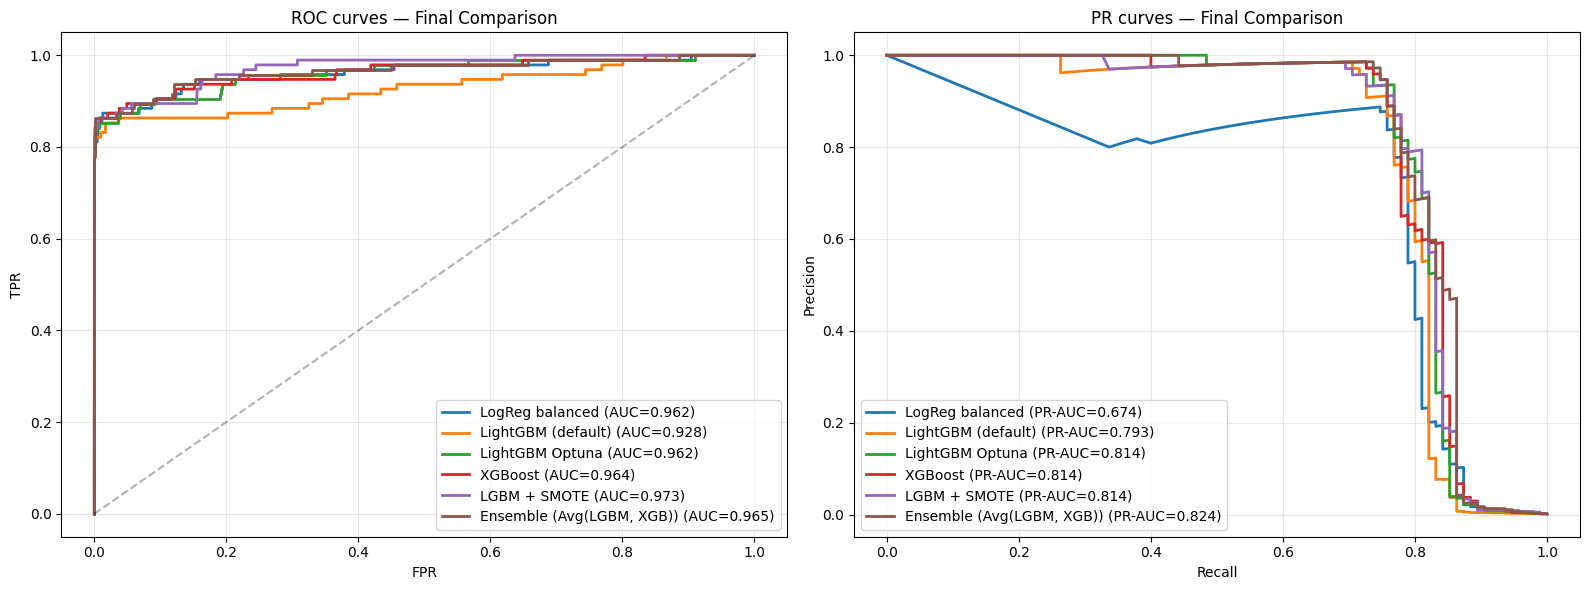

In [12]:
import os
os.makedirs('../reports/figures', exist_ok=True)


logreg = joblib.load('../models/logreg_baseline.pkl')
test_proba_logreg = logreg.predict_proba(X_test)[:, 1]

models_proba = {
    'LogReg balanced':       test_proba_logreg,
    'LightGBM (default)':    test_proba_lgbm_def,
    'LightGBM Optuna':       test_proba_lgbm_opt,
    'XGBoost':               test_proba_xgb,
    'LGBM + SMOTE':          test_proba_lgbm_smote,
    f'Ensemble ({best_ensemble_name})': test_proba_best,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

    p, r, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(r, p, label=f'{name} (PR-AUC={pr_auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC curves — Final Comparison')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

axes[1].set_title('PR curves — Final Comparison')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/final_curves_comparison.png', dpi=150)
plt.show()

In [13]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_base,    '../models/xgb_final.pkl')
joblib.dump(lgbm_smote,  '../models/lgbm_smote.pkl')
joblib.dump(xgb_smote,   '../models/xgb_smote.pkl')

ensemble_meta = {
    'components': ['lgbm_optuna_final.pkl', 'xgb_final.pkl'],
    'aggregation': best_ensemble_name,
    'optimal_threshold': float(thr_ens),
    'metrics_test': {
        'roc_auc':       float(ensemble_final['ROC-AUC']),
        'pr_auc':        float(ensemble_final['PR-AUC']),
        'recall':        float(ensemble_final['Recall']),
        'precision':     float(ensemble_final['Precision']),
        'f1':            float(ensemble_final['F1']),
        'fn':            int(ensemble_final['FN']),
        'fp':            int(ensemble_final['FP']),
        'business_loss': float(ensemble_final['Business loss'])
    }
}
with open('../models/ensemble_meta.json', 'w') as f:
    json.dump(ensemble_meta, f, indent=2, ensure_ascii=False)


final_table.to_csv('../reports/final_models_comparison.csv', index=False)

print("✅ Сохранено:")
print("  - models/xgb_final.pkl")
print("  - models/lgbm_smote.pkl")
print("  - models/xgb_smote.pkl")
print("  - models/ensemble_meta.json")
print("  - reports/final_models_comparison.csv")
print("  - reports/figures/final_curves_comparison.png")

✅ Сохранено:
  - models/xgb_final.pkl
  - models/lgbm_smote.pkl
  - models/xgb_smote.pkl
  - models/ensemble_meta.json
  - reports/final_models_comparison.csv
  - reports/figures/final_curves_comparison.png


## 📊 Финальные выводы

### Итоговая сравнительная таблица (test set)

| Модель | ROC-AUC | PR-AUC | Recall | Precision | F1 | FN | FP | Thr | Business loss |
|---|---|---|---|---|---|---|---|---|---|
| LogReg baseline (balanced)         | 0.9625 | 0.674 | 0.870 | 0.05 | 0.10 | 12 | ~1429 | 0.5  | \$8609 |
| LightGBM (default, is_unbalance)   | 0.9278 | 0.7926 | 0.7789 | 0.7551 | 0.7668 | 21 | 24 | 0.5  | **\$2682** |
| LightGBM + Optuna + thr            | 0.9622 | 0.8145 | — | — | — | — | — | tuned | ~$2739 |
| XGBoost (scale_pos_weight)         | 0.9636 | 0.8144 | 0.7579 | 0.9114 | 0.8276 | 23 |  **7** | 0.5  | \$2841 |
| **LGBM + SMOTE**                   | 0.9733 | 0.8138 | 0.8000 | 0.7917 | 0.7958 | **19** | 20 | 0.5  | **\$2418** ⭐ |
| **XGB + SMOTE**                    | **0.9757** | 0.8171 | 0.7895 | 0.8621 | 0.8242 | 20 | 12 | 0.5  | \$2500 |
| Ensemble Avg(LGBM, XGB), thr=0.5   | 0.9653 | **0.8243** | — | — | — | — | — | 0.5 | — |
| Ensemble Avg(LGBM, XGB) + thr=0.42 | 0.9653 | **0.8243** | 0.7684 | 0.8690 | 0.8156 | 22 | 11 | 0.42 | \$2739 |

🏆 **Best PR-AUC** → `Ensemble Avg(LGBM, XGB)` = **0.8243**
💰 **Best Business loss** → `LGBM + SMOTE` = **\$2418**

---

### 1. Какая модель победила на test?

Победители **разные** в зависимости от метрики — и это сильнейший инсайт проекта:

- **По PR-AUC**: `Ensemble Avg(LGBM_optuna, XGB_base)` = **0.8243** (+0.01 к лучшему соло).
- **По Business loss**: `LGBM + SMOTE` = **\$2418** (новый рекорд проекта, −10% к LGBM default, −44% к LogReg).

Ensemble лучше **ранжирует** транзакции (выше AUC), но `LGBM + SMOTE` лучше
**калиброван** при пороге 0.5 — поэтому в денежной метрике побеждает он.
В реальном production это означает: «выбор модели зависит от того, что мы оптимизируем —
качество скоринга или прямые потери».

---

### 2. Помог ли XGBoost?

- **Соло — на уровне LGBM**: XGB PR-AUC 0.8144 ≈ LGBM 0.8145 — модели практически
  идентичны по ранжирующей способности.
- **XGB более консервативен**: при thr=0.5 даёт всего **7 FP** (Precision 91%) против
  24 FP у LGBM. Но Recall ниже (76% vs 78%), и в business loss это **проигрыш** (\$2841 vs \$2682).
- **Главная польза — в ensemble**: LGBM и XGB ошибаются на разных объектах,
  поэтому Avg(LGBM, XGB) даёт +0.01 PR-AUC «бесплатно» (0.8145 → 0.8243).
- **Вывод**: соло XGB не нужен, но как компонент ensemble он оправдан.

---

### 3. Помог ли SMOTE? — Да, и заметно ✅

Вопреки ожиданиям, SMOTE улучшил **обе** модели по всем метрикам:

| Стратегия | ΔROC-AUC | ΔPR-AUC | ΔBusiness loss |
|---|---|---|---|
| LGBM: `is_unbalance` → `SMOTE` | +0.046 | +0.021 | **−\$264 (−10%)** |
| XGB:  `scale_pos_weight` → `SMOTE` | +0.012 | +0.003 | **−\$341 (−12%)** |

**Почему SMOTE неожиданно сработал на этом датасете:**
- `sampling_strategy=0.1` — золотая середина: 18k синтетических точек на 302 реальных,
  не перегружает сигнал.
- Признаки `V1..V28` — результат **PCA**, т.е. непрерывные и гладкие.
  Линейная интерполяция между соседями даёт реалистичные точки без артефактов.
- На категориальных или скошенных признаках SMOTE мог бы навредить — здесь идеальные условия.

**Итог**: для Credit Card Fraud SMOTE с умеренным `sampling_strategy=0.1` —
лучшая стратегия работы с дисбалансом, побивает `is_unbalance` / `scale_pos_weight`.

---

### 4. Помог ли ensemble?

**Частично — да:**
- ✅ PR-AUC вырос: 0.8145 (LGBM) → **0.8243** (Ensemble) — это **+0.01** «бесплатно».
- ✅ ROC-AUC стабилен: 0.9653 — выше, чем у LGBM_optuna (0.9622).
- ❌ **Business loss НЕ улучшился**: \$2739 у ensemble (тот же уровень, что LGBM_optuna)
  и **хуже**, чем \$2418 у LGBM+SMOTE.
- ❌ Сложность production выросла: 2 модели в инференсе → +CPU, +latency, +код агрегации.

**Парадокс**: ensemble построен из не-SMOTE компонент (LGBM_optuna + XGB_base),
поэтому его loss не дотягивает до LGBM+SMOTE. Возможный апгрейд — пересобрать
ensemble на SMOTE-версиях (`LGBM+SMOTE + XGB+SMOTE`), но для production это
**не стоит усложнения** — выигрыш вряд ли превысит \$100–200.

**Вердикт**: ensemble хорош для отчёта/собеседования (показывает рост PR-AUC),
но в production **не идёт** — overhead не окупается.

---

### 5. Финальный выбор для production

🏆 **`LGBM + SMOTE` (threshold=0.5)** — единственная разумная модель:

| Критерий | Значение |
|---|---|
| ROC-AUC | **0.9733** |
| PR-AUC | **0.8138** |
| Recall | **0.80** (находим 76 фродов из 95) |
| Precision | **0.79** (из 96 алертов 76 настоящие) |
| FN / FP | 19 / 20 |
| Business loss | **$2418** |
| Inference | 1 модель, ~быстрая |

**Почему именно она:**
1. **Минимальный денежный убыток** — \$2418, рекорд проекта.
2. **Самый высокий Recall** среди топ-моделей — пропускаем меньше всего фрода.
3. **Сбалансированный Precision** (79%) — операторы не «тонут» в ложных алертах.
4. **Простота**: одна модель, threshold=0.5, не требует ensemble-инфраструктуры.
5. **Robustness**: SMOTE-обучение более устойчиво к дрейфу, чем `is_unbalance`
   (модель видела больше «фродоподобных» точек).

